# Probabilistic Model Using VED

Volumetric Energy Density (VED) is the amount of energy (capacity, kWh) that can be stored in a given volume or how much laser energy is applied per unit volume of material.

**VED = P/vth**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

This model predicts a **distribution** of fatigue lives instead of one value.

Here, VED is a **process input** that controls defect statistics.

# Imports

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.stats import weibull_min

# Variables

In [215]:
# C, material const., calibrated experimentally
# set values to calibrate C
stress_amp = 100        # stress amplitude
defect_size = 100       # defect size
N_target = 1e5          # target N for these values        
m = 2.7                 # sensitivity to stress
n = 1.5                 # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))
Y = 1.0                 # geometry factor

# calibrate C given these values
C = N_target * (stress_amp**m) * (defect_size**n)

In [216]:
# define fxn to calculate the number of defects, n_defects, from VED
def calculate_Nd(rho, volume):
    N_defects = np.random.poisson(rho * volume)
    return N_defects

In [217]:
V = 1000                    # volume of material [mm^3]
rho_defects = 0.01          # defect density [defects/mm^3]

# calculate number of defects from VED
n_defects = calculate_Nd(rho_defects, V)  # example values for rho and volume

In [218]:
# process parameters
P = 200          # laser power [W]
v = 800          # scan speed [mm/s]
h = 0.10         # hatch spacing [mm]
t = 0.03         # layer thickness [mm]

# volumetric energy density
VED = P / (v * h * t)

print("VED =", VED, "J/mm^3")

VED = 83.33333333333334 J/mm^3


# Functions

## Defect Density

In [219]:
V_specimen = 1.0                # inspected specimen volume [mm^3]

# define fxn for defect density model
def defect_density(VED):
    VED_opt = 80        # optimal VED
    rho_min = 50        # min defect density at optimal VED [defects/mm^3]
    alpha = 0.08        # sensitivity of defect density to VED deviations

    # U-shaped defect density curve
    rho = rho_min + alpha * (VED - VED_opt)**2

    return rho

In [220]:
# defect density for this VED
rho_defects = defect_density(VED)

# expected number of defects
lambda_defects = rho_defects * V_specimen

print("Defect density =", rho_defects, "defects/mm^3")
print("Expected number of defects =", lambda_defects, "defects/mm^3")

Defect density = 50.88888888888889 defects/mm^3
Expected number of defects = 50.88888888888889 defects/mm^3


## Data

Data generated from Poisson distribution

In [221]:
# define fxns to calculate defect size distribution parameters from VED
def defect_mu(VED):
    VED_opt = 80                        # optimal VED
    return 3.5 + 0.002 * (VED - VED_opt)**2

def defect_sigma(VED):
    VED_opt = 80                        # optimal VED
    return  0.35

mu = defect_mu(VED)         # mean of log, ~3-6
sigma = defect_sigma(VED)   # std dev of log, ~0.2-1

print("Defect size distribution parameters: mu =", mu, ", sigma =", sigma)

Defect size distribution parameters: mu = 3.522222222222222 , sigma = 0.35


In [222]:
# define fxn to generate defects based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

In [223]:
# sample number of defects from Poisson distribution
n_local = np.random.poisson(lambda_defects)

# avoid empty specimen
n_local = max(n_local, 1)

# generate defects
defects = generate_defects(n_local, mu, sigma)

### Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

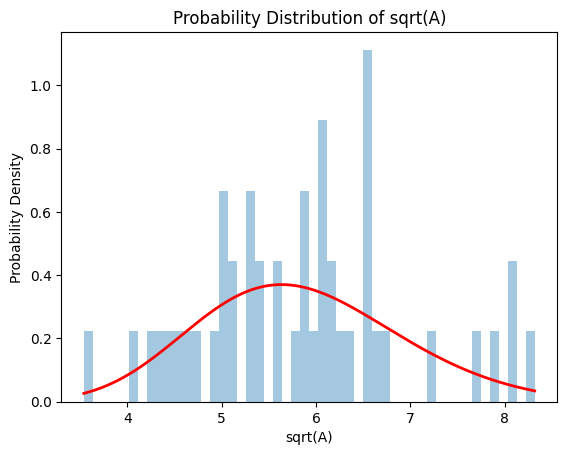

In [224]:
# create probabilistic curve
sqrtA = np.sqrt(defects)

# calculate GEV fit from generated data
c, loc, scale = genextreme.fit(sqrtA)

x = np.linspace(min(sqrtA), max(sqrtA), 500)
pdf = genextreme.pdf(x, c, loc, scale)

# plot histogram and GEV fit
plt.hist(sqrtA, bins=50, density=True, alpha=0.4)
plt.plot(x, pdf, linewidth=2, color='red')

plt.title('Probability Distribution of sqrt(A)')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability Density')

plt.show()

## Critical Defects
The critical defect is the one that leads to failure. Assume this is the largest defect.

The critical (max) defect is found.

In [225]:
# define fxn to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 69.1895836149595


## Fatigue Life

Fatigue life or the number of cycles, N, is determined based on,

**N = C / (stress_amp^m * A^n)**

In [226]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## Shiozawa Model

The stress intensity factor, delta(K), the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [227]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# Defect Density vs. VED Plot

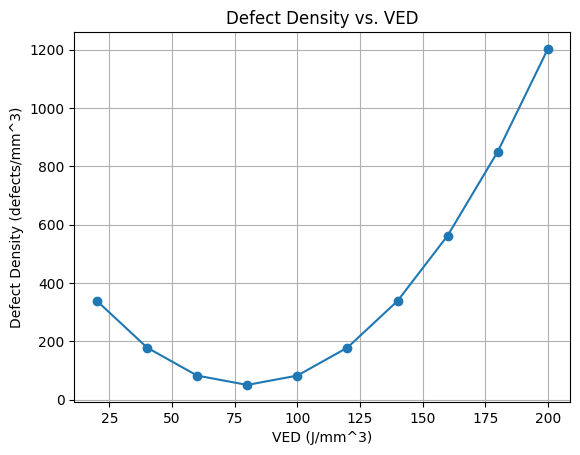

In [228]:
# vary VED
VED_vals = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]

rho_vals = []       # list to store density values for each VED

for VED_i in VED_vals:
    rho = defect_density(VED_i)
    rho_vals.append(rho)

plt.plot(VED_vals, rho_vals, marker='o')

# axis labels
plt.title('Defect Density vs. VED')
plt.xlabel('VED (J/mm^3)')
plt.ylabel('Defect Density (defects/mm^3)')

plt.grid()

plt.show()


# Monte Carlo Loop

simulate randomness many times

Each specimen has random defects. So:
- n_defects number of virtual specimens is generated
- each specimen gets random defects
- the critical defect is calculated for each
- the distribution of fatigue lives is predicted
- the life distribution is observed

## Fixed Stress

In [229]:
# set fixed stress amplitude, S, [MPa]
S_fixed = 250

# list to store results
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
K = []              # list to store stress intensity factors
N_norm = []         # list to store normalized fatigue lives

for i in range(1000):
    # random no. of defects for this specimen
    n_local = calculate_Nd(rho_defects, V_specimen)

    # avoid empty specimen
    n_local = max(n_local, 1)                       

    defects = generate_defects(n_local, mu, sigma)

    A_crit = critical_defect(defects)
    N = fatigue_life(S_fixed, A_crit, C, m, n)
    Murakami = np.sqrt(A_crit)                      # Murakami parameter for defect size, sqrt(A)
    delta_K = stress_intensity_factor(S_fixed, A_crit)
    N_normal = N / Murakami                         # normalized fatigue life, N / sqrt(A)     

    # store results
    lives.append(N)
    M.append(Murakami)
    max_defects.append(A_crit)
    K.append(delta_K)
    N_norm.append(N_normal)

### Fatigue Life

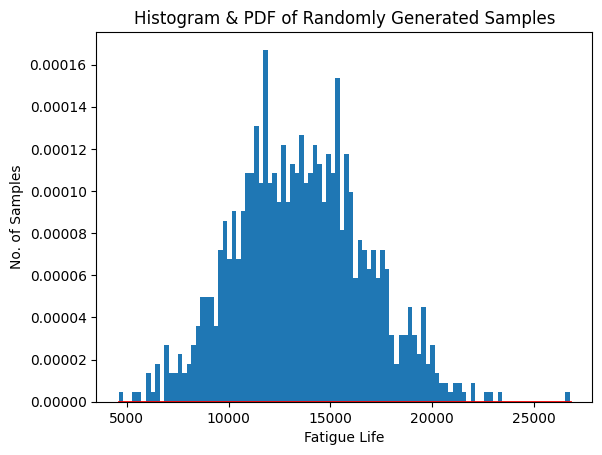

In [230]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x1)-mu)**2/(2*sigma**2))
       /(x1*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=2, color='r')
plt.axis('tight')
plt.show()

In [231]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 13574.719804921486
The standard deviation of the fatigue life is 3181.549785043947


### GEV, P vs sqrt(A)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

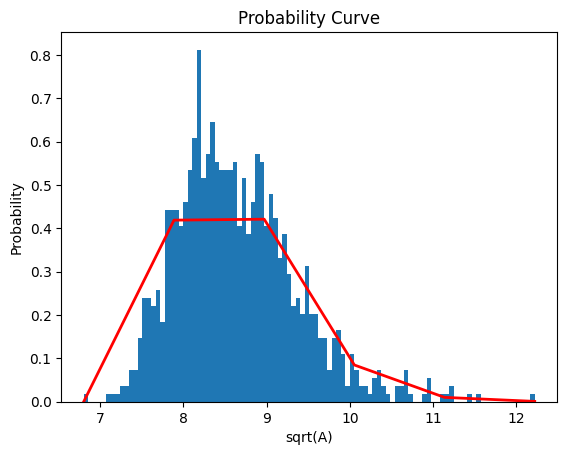

In [232]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density fxn
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Shiozawa Curves

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

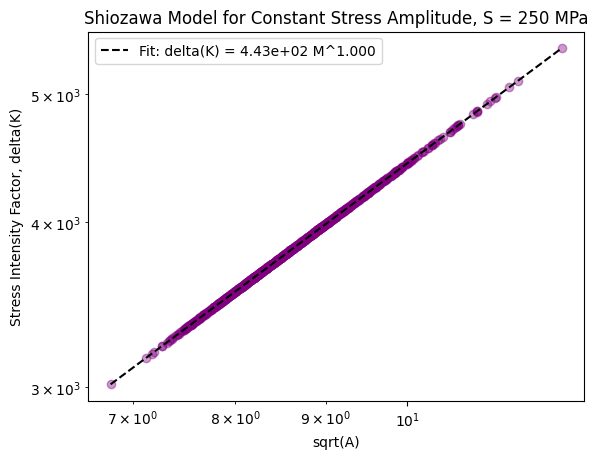

In [233]:
# log transform
logM = np.log10(M)
logK = np.log10(K)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logM, logK, 1)
a = 10**loga

# fitted curve
M_line = np.logspace(np.log10(min(M)), np.log10(max(M)), 200)
K_line = a * M_line**b

# scatter plot of delta(K) vs sqrt(A)
plt.scatter(M, K, alpha=0.4, color='purple')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

Under constant stress, as the size of the defect increases, the stress intensity factor increases exponentially since both x and y, delta(K) and sqrt(A), respectively, are log-transformed.

#### Confidence Intervals

In [234]:
logM = np.log10(M)

# create bins for logM
bins = np.linspace(min(logM), max(logM), 20)

# calculate mean and std dev of stress values in each bin
K_avg = []
K_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logM >= bins[i]) & (logM < bins[i+1])
    Ks_in_bin = np.array(K)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    K_avg.append(np.mean(Ks_in_bin))
    K_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins[i] + bins[i+1]))

K_avg = np.array(K_avg)
K_std = np.array(K_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = K_avg + 1.96 * K_std
lower_K = K_avg - 1.96 * K_std

upper = np.array(upper_K)
lower = np.array(lower_K)

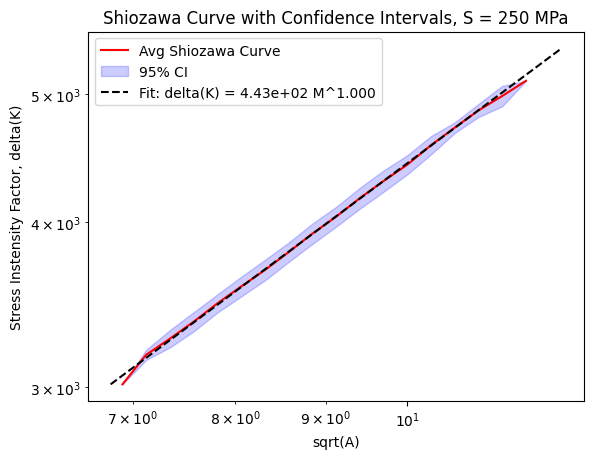

In [235]:
xvals1 = np.power(10, centers)

plt.plot(xvals1, K_avg, 'red', label='Avg Shiozawa Curve')

plt.fill_between(xvals1, lower_K, upper_K,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Curve with Confidence Intervals, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Instensity Factor, delta(K)')

plt.legend()
plt.show()

The narrow confidence intervals imply a good certainty in the estimate.

### Reliability Curves
the probability a specimen survives beyond a given 

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [236]:
# sort fatigue lives
lives_sorted = np.sort(np.array(lives))

# calculate survival probability
j = len(lives_sorted)
R = 1 - np.arange(j) / j

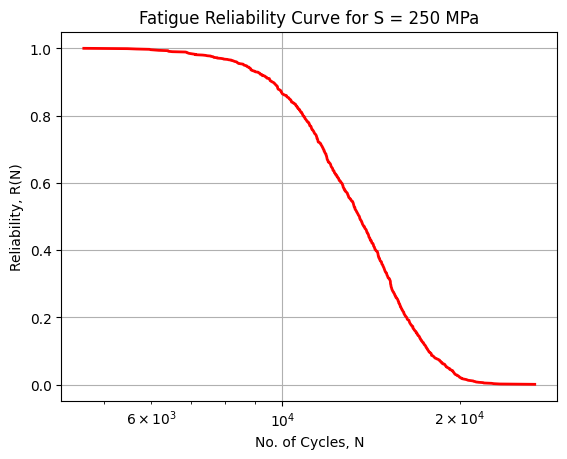

In [237]:
# plot reliability curve
plt.plot(lives_sorted, R,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near one, almost nothing has failed yet. Then the curve drops: at around 50%, reliability has decreased and about half have failed. Finally, reliability approaches zero, so around 1100 cycles, almost all specimens have failed.

#### Weibull Reliability Model
This is more of a **statistical reliability model** rather than a crack-growth physics model.

Instead of simulating defects directly, failure probability is modeled with a Weibull distribution.

Typically, **R(N) = exp[-(N/η)^β]**

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

This model describes how failure probability evolves with cycles.

In [238]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals = np.linspace(min(lives), max(lives), 200)
R_theory = np.exp(-(N_vals / scale)**shape)

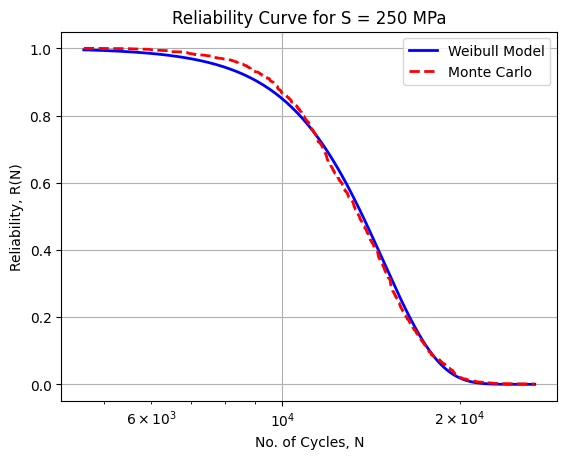

In [239]:
# plot theoretical reliability curve
plt.plot(N_vals, R_theory,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted = np.sort(lives)
R_emp = 1 - np.arange(len(lives)) / len(lives)

plt.plot(lives_sorted, R_emp,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are mostly close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior pretty well.

### Normalized Life
plot **delta(K_i) vs N/sqrt(A)**
where N/sqrt(A) = defect-normalized life

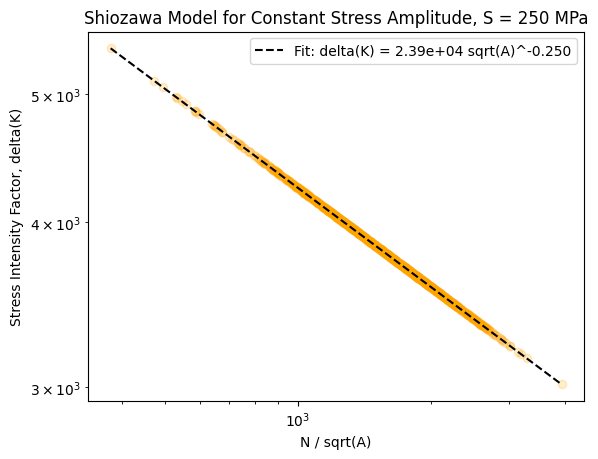

In [240]:
# log transform
logN_norm = np.log10(N_norm)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logN_norm, logK, 1)
a = 10**loga

# fitted curve
N_norm_line = np.logspace(np.log10(min(N_norm)), np.log10(max(N_norm)), 200)
K_line = a * N_norm_line**b

# scatter plot of delta(K) vs N/sqrt(A)
plt.scatter(N_norm, K, alpha=0.2, color='orange')

# plot fit
plt.plot(N_norm_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} sqrt(A)^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

## Varying Sress

### Shiowaza Curve
with normalized life plot **delta(K_i) vs N/sqrt(A)** where N/sqrt(A) = defect-normalized life

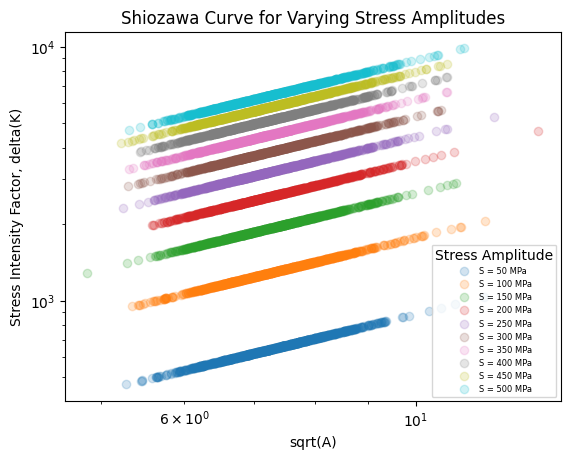

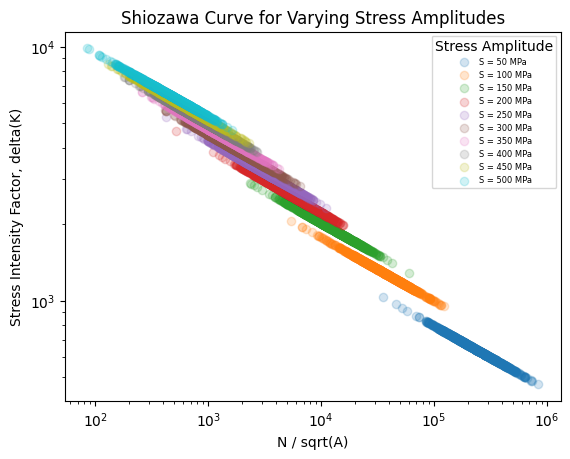

In [241]:
# vary stress amplitude, S
S_vals = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

for S_i in S_vals:

    # temporary lists for this stress amplitude
    M_temp = []
    K_temp = []
    N_norm_temp = []

    lives_temp = []
    max_defects_temp = []

    for i in range(1000):
        # random number of defects for this specimen
        n_local = calculate_Nd(rho_defects, V_specimen)
        
        # avoid empty specimen
        n_local = max(n_local, 1)

        defects = generate_defects(n_defects, mu, sigma)

        A_crit1 = critical_defect(defects)
        Murakami1 = np.sqrt(A_crit1)
        delta_K1 = stress_intensity_factor(S_i, A_crit1)
        N1 = fatigue_life(S_i, A_crit1, C, m, n)
        N_normal1 = N1 / Murakami1

        # store points for this stress amplitude
        M_temp.append(Murakami1)
        K_temp.append(delta_K1)
        N_norm_temp.append(N_normal1)

        lives_temp.append(N1)
        max_defects_temp.append(np.max(defects))
        
    # plot 1: delta(K) vs sqrt(A), for all points at this stress amplitude
    plt.figure(1)
    plt.scatter(M_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

    # plot 2: delta(K) vs N/sqrt(A) for this stress amplitude
    plt.figure(2)
    plt.scatter(N_norm_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

# figure 1: delta(K) vs sqrt(A)
plt.figure(1)

plt.xscale('log')
plt.yscale('log')

# figure 1: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# log scales
plt.xscale('log')
plt.yscale('log')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# figure 2: delta(K) vs N/sqrt(A)
plt.figure(2)

plt.xscale('log')
plt.yscale('log')

# figure 2: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='upper right')

plt.show()

A higher stress amplitude results in a higher stress intensity factor.
The stress intensity factor and Murakami factor are related exponentially since both axes are log-transformed.

### Reliability Curves
the probability a specimen survives beyond a given life

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [242]:
# sort fatigue lives
lives_sorted1 = np.sort(np.array(lives_temp))

# calculate survival probability
j1 = len(lives_sorted1)
R1 = 1 - np.arange(j1) / j1

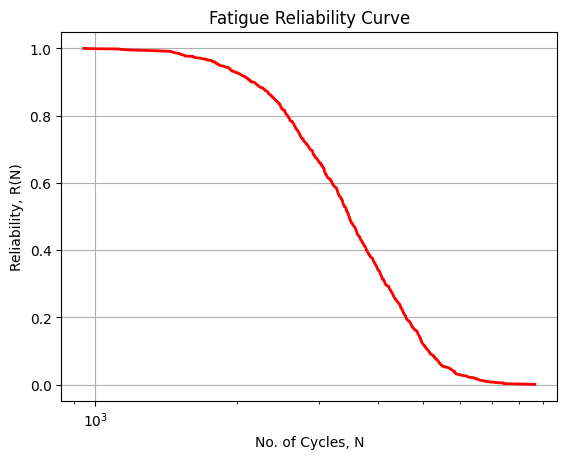

In [243]:
# plot reliability curve
plt.plot(lives_sorted1, R1,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near 100% reliability, almost nothing has failed yet. At around 60%, reliability has decreased and almost half the specimens have failed. Finally, reliability approaches zero, so around 130 cycles, almost all specimens have failed.

#### Weibull Reliability Model
R(N) = exp[-(N/eta)^beta]

In [244]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives_temp, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals1 = np.linspace(min(lives_temp), max(lives_temp), 200)
R_theory1 = np.exp(-(N_vals1 / scale)**shape)

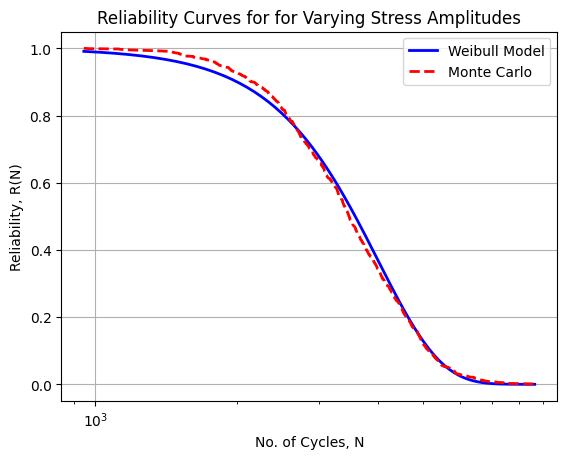

In [245]:
# plot theoretical reliability curve
plt.plot(N_vals1, R_theory1,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted1 = np.sort(lives_temp)
R_emp1 = 1 - np.arange(len(lives_temp)) / len(lives_temp)

plt.plot(lives_sorted1, R_emp1,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curves for for Varying Stress Amplitudes")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are mostly close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior pretty well.